# Final model comparison and error analysis

This notebook compares the selected LightGBM baseline with SchNet, tests whether their errors are complementary, and evaluates a validation-selected weighted ensemble. It reuses saved metrics, predictions, checkpoints, and deterministic feature caches; no new architecture is introduced.

## 1. Setup and exact split reproduction

In [1]:
from collections import Counter
from pathlib import Path
import json
import os
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from rdkit import Chem
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import torch
from torch import nn
from torch.utils.data import Subset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn.models import SchNet
from lightgbm import LGBMRegressor

RANDOM_STATE = 42

def seed_everything(seed=RANDOM_STATE):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path.cwd()
if not (ROOT / "datasets" / "base.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "datasets" / "base.csv").exists():
    raise FileNotFoundError("Run from the repository root or notebooks/.")
DATA_PATH = ROOT / "datasets" / "base.csv"
RESULTS_DIR = ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "final_figures"
MODEL_DIR = RESULTS_DIR / "models"
CACHE_DIR = ROOT / "outputs" / "cache"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path.relative_to(ROOT)

df = pd.read_csv(DATA_PATH)
if "mol_id" not in df and str(df.columns[0]).startswith("Unnamed"):
    df = df.rename(columns={df.columns[0]: "mol_id"})
labeled = df.loc[df["gap"].notna(), ["mol_id", "json_conformer", "gap"]].reset_index(drop=True)
y = labeled["gap"].to_numpy(dtype=np.float32)
cache_tag = f"{len(labeled)}_{int(DATA_PATH.stat().st_mtime)}"

graph_cache = torch.load(
    CACHE_DIR / f"schnet_graphs_{cache_tag}.pt", map_location="cpu", weights_only=False
)
atomic_numbers = graph_cache["atomic_numbers"]
positions = graph_cache["positions"]
scaffolds = np.asarray(graph_cache["scaffolds"], dtype=str)
n_atoms = np.asarray([len(z) for z in atomic_numbers])
graphs = [
    Data(z=z, pos=pos, y=torch.tensor([target], dtype=torch.float32))
    for z, pos, target in zip(atomic_numbers, positions, y)
]

all_idx = np.arange(len(labeled))
random_train_idx, random_temp_idx = train_test_split(
    all_idx, test_size=0.30, random_state=RANDOM_STATE
)
random_val_idx, random_test_idx = train_test_split(
    random_temp_idx, test_size=0.50, random_state=RANDOM_STATE
)
scaffold_groups = {}
for idx, scaffold in enumerate(scaffolds):
    scaffold_groups.setdefault(scaffold, []).append(idx)
ordered_groups = sorted(scaffold_groups.items(), key=lambda item: (-len(item[1]), item[0]))
train_cutoff, validation_cutoff = int(.70 * len(labeled)), int(.85 * len(labeled))
scaffold_train, scaffold_validation, scaffold_test = [], [], []
for _, group_indices in ordered_groups:
    if len(scaffold_train) + len(group_indices) <= train_cutoff:
        scaffold_train.extend(group_indices)
    elif len(scaffold_train) + len(scaffold_validation) + len(group_indices) <= validation_cutoff:
        scaffold_validation.extend(group_indices)
    else:
        scaffold_test.extend(group_indices)
scaffold_train_idx = np.asarray(scaffold_train, dtype=int)
scaffold_val_idx = np.asarray(scaffold_validation, dtype=int)
scaffold_test_idx = np.asarray(scaffold_test, dtype=int)

splits = {
    "random": (random_train_idx, random_val_idx, random_test_idx),
    "scaffold": (scaffold_train_idx, scaffold_val_idx, scaffold_test_idx),
}
display(pd.DataFrame([
    {"split": name, "train": len(indices[0]), "validation": len(indices[1]), "test": len(indices[2])}
    for name, indices in splits.items()
]).set_index("split"))

,train,validation,test
split,,,
random,39995,8570,8571
scaffold,39995,8570,8571


## 2. Load checkpoints and reproduce only missing predictions

Random-test predictions are loaded from notebook 03. SchNet validation/scaffold predictions come from saved checkpoints. LightGBM is refitted only because validation and scaffold predictions were not saved previously; it uses the exact cached features and selected configuration from notebook 02.

In [2]:
class DenseRadiusInteractionGraph(nn.Module):
    def __init__(self, cutoff):
        super().__init__()
        self.cutoff = cutoff
    def forward(self, pos, batch):
        distances = torch.cdist(pos, pos)
        mask = batch[:, None].eq(batch[None, :]) & distances.gt(0) & distances.lt(self.cutoff)
        edge_index = mask.nonzero(as_tuple=False).T.contiguous()
        row, col = edge_index
        return edge_index, distances[row, col]

def optional_interaction_graph(cutoff):
    try:
        import pyg_lib  # noqa: F401
        return None
    except ImportError:
        return DenseRadiusInteractionGraph(cutoff)

def load_schnet(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    config = checkpoint["config"]
    model = SchNet(
        hidden_channels=config["hidden_channels"],
        num_filters=config["hidden_channels"],
        num_interactions=config["num_interactions"],
        num_gaussians=25,
        cutoff=config["cutoff"],
        interaction_graph=optional_interaction_graph(config["cutoff"]),
        max_num_neighbors=32,
        readout="mean",
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, config

def make_loader(indices, batch_size):
    return DataLoader(Subset(graphs, indices.tolist()), batch_size=batch_size,
                      shuffle=False, num_workers=0)

@torch.no_grad()
def schnet_predict(model, indices, batch_size):
    targets, predictions = [], []
    for batch in make_loader(indices, batch_size):
        batch = batch.to(DEVICE)
        predictions.append(model(batch.z, batch.pos, batch.batch).view(-1).cpu())
        targets.append(batch.y.view(-1).cpu())
    return torch.cat(targets).numpy(), torch.cat(predictions).numpy()

random_schnet, random_config = load_schnet(MODEL_DIR / "schnet_best_random.pt")
scaffold_schnet, scaffold_config = load_schnet(MODEL_DIR / "schnet_best_scaffold.pt")
random_val_true, random_schnet_val = schnet_predict(
    random_schnet, random_val_idx, random_config["batch_size"] * 2
)
scaffold_val_true, scaffold_schnet_val = schnet_predict(
    scaffold_schnet, scaffold_val_idx, scaffold_config["batch_size"] * 2
)
scaffold_test_true, scaffold_schnet_test = schnet_predict(
    scaffold_schnet, scaffold_test_idx, scaffold_config["batch_size"] * 2
)

saved_random = pd.read_csv(RESULTS_DIR / "schnet_vs_lightgbm_molecule_analysis.csv")
assert np.array_equal(saved_random["mol_id"].to_numpy(), labeled.iloc[random_test_idx]["mol_id"].to_numpy())
random_test_true = saved_random["true_gap"].to_numpy()
random_schnet_test = saved_random["schnet_prediction"].to_numpy()
random_lgbm_test_saved = saved_random["lightgbm_prediction"].to_numpy()

dense_cache = np.load(CACHE_DIR / f"classical_dense_{cache_tag}.npz")
X_size = dense_cache["X_size"]
X_geometry = dense_cache["X_geometry"]
X_rdkit = dense_cache["X_rdkit"]
X_morgan = sparse.load_npz(CACHE_DIR / f"classical_morgan_{cache_tag}.npz").tocsr()
X_combined = sparse.hstack(
    [X_morgan, sparse.csr_matrix(X_rdkit), sparse.csr_matrix(X_geometry)],
    format="csr", dtype=np.float32,
)

classical_metrics = pd.read_csv(RESULTS_DIR / "classical_baselines.csv")
best_classical_random = classical_metrics.query("split_strategy == 'random'").sort_values("validation_mae").iloc[0]
classical_family = best_classical_random["model"]
selected_params = json.loads(best_classical_random["selected_parameters"])

def make_lgbm_pipeline():
    n_fp = X_morgan.shape[1]
    return Pipeline([
        ("preprocess", ColumnTransformer([
            ("fingerprint", "passthrough", slice(0, n_fp)),
            ("descriptors", SimpleImputer(strategy="median"), slice(n_fp, X_combined.shape[1])),
        ], sparse_threshold=1.0)),
        ("regressor", LGBMRegressor(
            objective="regression_l1", n_estimators=30, learning_rate=.1,
            num_leaves=selected_params["num_leaves"],
            min_child_samples=selected_params["min_child_samples"],
            subsample=.9, colsample_bytree=.5, max_bin=63, reg_lambda=1.,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        )),
    ])

random_lgbm = make_lgbm_pipeline()
random_lgbm.fit(X_combined[random_train_idx], y[random_train_idx])
random_lgbm_val = random_lgbm.predict(X_combined[random_val_idx])
random_lgbm_test_check = random_lgbm.predict(X_combined[random_test_idx])
print("Saved/reproduced random LightGBM max difference:",
      np.max(np.abs(random_lgbm_test_saved - random_lgbm_test_check)))
random_lgbm_test = random_lgbm_test_saved

scaffold_lgbm = make_lgbm_pipeline()
scaffold_lgbm.fit(X_combined[scaffold_train_idx], y[scaffold_train_idx])
scaffold_lgbm_val = scaffold_lgbm.predict(X_combined[scaffold_val_idx])
scaffold_lgbm_test = scaffold_lgbm.predict(X_combined[scaffold_test_idx])

Saved/reproduced random LightGBM max difference: 8.326672684688674e-17


## 3. Consolidated model results

In [3]:
schnet_metrics = pd.read_csv(RESULTS_DIR / "schnet_metrics.csv")
base_rows = schnet_metrics.copy()
base_rows["absolute_test_mae_difference_vs_lightgbm"] = np.nan
base_rows["relative_test_mae_difference_vs_lightgbm_pct"] = np.nan
for split_name in ["random", "scaffold"]:
    reference = base_rows[(base_rows["split"] == split_name) & base_rows["model"].str.contains("LightGBM")]["test_mae"].iloc[0]
    mask = base_rows["split"].eq(split_name)
    base_rows.loc[mask, "absolute_test_mae_difference_vs_lightgbm"] = base_rows.loc[mask, "test_mae"] - reference
    base_rows.loc[mask, "relative_test_mae_difference_vs_lightgbm_pct"] = (
        100 * (base_rows.loc[mask, "test_mae"] - reference) / reference
    )
display(base_rows)

wide_summary = base_rows.pivot(index="split", columns="model", values="test_mae")
wide_summary["schnet_minus_lightgbm_absolute"] = (
    wide_summary["SchNet"] - wide_summary[classical_family]
)
wide_summary["schnet_minus_lightgbm_relative_pct"] = (
    100 * wide_summary["schnet_minus_lightgbm_absolute"] / wide_summary[classical_family]
)
display(wide_summary)

,split,model,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,trainable_parameters,absolute_test_mae_difference_vs_lightgbm,relative_test_mae_difference_vs_lightgbm_pct
0,random,SchNet,0.014243,0.014572,0.366911,0.019825,356.445986,13793.0,0.000311,2.182114
1,random,Morgan + RDKit 2D + simple 3D + LightGBM,0.013886,0.014261,0.367294,0.017775,106.245370,NaN,0.000000,0.000000
2,scaffold,SchNet,0.013148,0.019954,0.514755,0.012527,331.613799,13793.0,-0.001866,-8.553538
3,scaffold,Morgan + RDKit 2D + simple 3D + LightGBM,0.014583,0.021821,0.515300,0.010435,66.518367,NaN,0.000000,0.000000


model,Morgan + RDKit 2D + simple 3D + LightGBM,SchNet,schnet_minus_lightgbm_absolute,schnet_minus_lightgbm_relative_pct
split,,,,
random,0.014261,0.014572,0.000311,2.182114
scaffold,0.021821,0.019954,-0.001866,-8.553538


## 4. Comparative per-molecule error data

In [4]:
SIZE_NAMES = [
    "n_atoms", "n_heavy_atoms", "n_bonds", "n_atom_types",
    "element_H", "element_C", "element_N", "element_O", "element_F",
    "bond_type_1", "bond_type_1.5", "bond_type_2", "bond_type_3",
]
GEOMETRY_NAMES = [
    "radius_of_gyration", "mean_bond_length", "std_bond_length",
    "max_atomic_distance", "coordinate_cov_eigenvalue_1",
    "coordinate_cov_eigenvalue_2", "coordinate_cov_eigenvalue_3",
]

def build_prediction_frame(split_name, train_idx, test_idx, true, lgbm_pred, schnet_pred):
    train_scaffold_frequency = pd.Series(scaffolds[train_idx]).value_counts()
    frame = pd.DataFrame({
        "dataset_index": test_idx,
        "mol_id": labeled.iloc[test_idx]["mol_id"].to_numpy(),
        "target": true,
        "lightgbm_prediction": lgbm_pred,
        "schnet_prediction": schnet_pred,
        "lightgbm_absolute_error": np.abs(true - lgbm_pred),
        "schnet_absolute_error": np.abs(true - schnet_pred),
        "scaffold": scaffolds[test_idx],
        "scaffold_train_frequency": [
            int(train_scaffold_frequency.get(scaffold, 0)) for scaffold in scaffolds[test_idx]
        ],
    })
    frame["schnet_improvement"] = (
        frame["lightgbm_absolute_error"] - frame["schnet_absolute_error"]
    )
    for column, values in zip(SIZE_NAMES, X_size[test_idx].T):
        frame[column] = values
    for column, values in zip(GEOMETRY_NAMES, X_geometry[test_idx].T):
        frame[column] = values
    frame["smiles"] = [
        Chem.MolToSmiles(Chem.RemoveHs(Chem.JSONToMols(js)[0]), canonical=True)
        for js in labeled.iloc[test_idx]["json_conformer"]
    ]
    frame["split"] = split_name
    return frame

random_predictions = build_prediction_frame(
    "random", random_train_idx, random_test_idx,
    random_test_true, random_lgbm_test, random_schnet_test,
)
scaffold_predictions = build_prediction_frame(
    "scaffold", scaffold_train_idx, scaffold_test_idx,
    scaffold_test_true, scaffold_lgbm_test, scaffold_schnet_test,
)

random_predictions.to_csv(RESULTS_DIR / "final_predictions_random_test.csv", index=False)
scaffold_predictions.to_csv(RESULTS_DIR / "final_predictions_scaffold_test.csv", index=False)

def safe_spearman(left, right):
    if left.nunique(dropna=True) < 2 or right.nunique(dropna=True) < 2:
        return np.nan
    return left.corr(right, method="spearman")

def error_associations(frame):
    numeric = ["target", "n_atoms", "n_heavy_atoms", "scaffold_train_frequency"] + GEOMETRY_NAMES
    return pd.DataFrame({
        "lightgbm_error_spearman": [
            safe_spearman(frame[column], frame["lightgbm_absolute_error"]) for column in numeric
        ],
        "schnet_error_spearman": [
            safe_spearman(frame[column], frame["schnet_absolute_error"]) for column in numeric
        ],
        "schnet_improvement_spearman": [
            safe_spearman(frame[column], frame["schnet_improvement"]) for column in numeric
        ],
    }, index=numeric)

display(Markdown("**Random-test error associations**"))
display(error_associations(random_predictions))
display(Markdown("**Scaffold-test error associations**"))
display(error_associations(scaffold_predictions))

element_rows = []
for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    for element in ["C", "N", "O", "F"]:
        present = frame[f"element_{element}"] > 0
        element_rows.append({
            "split": split_name, "element": element,
            "molecules_with_element": int(present.sum()),
            "mean_schnet_improvement": frame.loc[present, "schnet_improvement"].mean(),
            "median_schnet_improvement": frame.loc[present, "schnet_improvement"].median(),
        })
element_analysis = pd.DataFrame(element_rows)
display(Markdown("**Element-composition summary (positive favors SchNet)**"))
display(element_analysis)

**Random-test error associations**

,lightgbm_error_spearman,schnet_error_spearman,schnet_improvement_spearman
target,-0.085437,-0.106662,0.002255
n_atoms,-0.185608,-0.105730,-0.068192
n_heavy_atoms,0.027794,-0.013821,0.036184
scaffold_train_frequency,-0.047112,0.005378,-0.038134
radius_of_gyration,-0.077067,-0.036389,-0.025835
mean_bond_length,0.057017,0.012902,0.024803
std_bond_length,-0.098678,-0.074176,-0.036679
max_atomic_distance,-0.060035,-0.034884,-0.011257
coordinate_cov_eigenvalue_1,-0.132870,-0.095080,-0.044502
coordinate_cov_eigenvalue_2,-0.014558,-0.019652,0.004527


**Scaffold-test error associations**

,lightgbm_error_spearman,schnet_error_spearman,schnet_improvement_spearman
target,-0.068577,0.001784,-0.124325
n_atoms,-0.102548,-0.030718,-0.073587
n_heavy_atoms,0.015511,0.053020,-0.017412
scaffold_train_frequency,NaN,NaN,NaN
radius_of_gyration,-0.083107,-0.016474,-0.057272
mean_bond_length,0.175626,0.088241,0.110349
std_bond_length,0.024427,-0.013209,0.048796
max_atomic_distance,-0.065474,-0.012388,-0.044725
coordinate_cov_eigenvalue_1,-0.038844,-0.040678,-0.009342
coordinate_cov_eigenvalue_2,-0.048026,0.016808,-0.053929


**Element-composition summary (positive favors SchNet)**

,split,element,molecules_with_element,mean_schnet_improvement,median_schnet_improvement
0,random,C,8571,-0.000311,-0.000637
1,random,N,5253,0.000445,-0.000200
2,random,O,7275,-0.000501,-0.000642
3,random,F,147,0.002793,0.001147
4,scaffold,C,8571,0.001866,0.000362
5,scaffold,N,5327,0.001964,0.000524
6,scaffold,O,7293,0.001069,0.000016
7,scaffold,F,3,0.012312,0.001486


## 5. Difficult molecules

In [5]:
def difficult_tables(frame, n=12):
    scored = frame.copy()
    scored["both_models_error"] = scored[
        ["lightgbm_absolute_error", "schnet_absolute_error"]
    ].min(axis=1)
    columns = [
        "mol_id", "target", "lightgbm_prediction", "schnet_prediction",
        "lightgbm_absolute_error", "schnet_absolute_error",
        "scaffold_train_frequency", "n_atoms", "n_heavy_atoms", "smiles",
    ]
    return {
        "Both models predict poorly": scored.nlargest(n, "both_models_error")[columns],
        "Strongly improved by SchNet": scored.nlargest(n, "schnet_improvement")[columns],
        "Strongly improved by LightGBM": scored.nsmallest(n, "schnet_improvement")[columns],
    }

for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    display(Markdown(f"### {split_name.title()} test"))
    for title, table in difficult_tables(frame).items():
        display(Markdown(f"**{title}**"))
        display(table)

display(Markdown(
    "These rankings identify candidates for chemical review; they do not establish a causal "
    "relationship between a substructure and model performance."
))

### Random test

**Both models predict poorly**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
6589,79512,34.2900,0.313908,0.346879,33.976092,33.943121,0,21.0,9.0,[C@@H3][C@@]12[C@H2][C@@]([C@@H3])([C@H2]1)[C@...
7649,109643,0.1494,0.233937,0.246603,0.084537,0.097203,0,14.0,9.0,O[C@@]12[C@@H]3[C@H]4O[C@@H]3[NH2+][C@@H]1[C@H]42
7995,106077,0.1547,0.233542,0.247382,0.078842,0.092682,0,13.0,8.0,[NH2+]1[C@H]2[C@@H]3[C@H]2[C@@H]2O[C@H]1[C@@H]23
5984,43658,0.1550,0.232752,0.246061,0.077752,0.091061,0,16.0,9.0,[C@@H3][C@@]12[NH2+][C@@H]3O[C@H]4[C@@H]3[C@@H...
305,51019,0.1549,0.230754,0.235912,0.075854,0.081012,0,17.0,9.0,[C@@H3][C@@]12[C@@H]3[C@H]4[C@@H2][NH2+][C@@H]...
884,23280,0.1738,0.324288,0.248554,0.150488,0.074754,0,18.0,8.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
2670,95176,0.1521,0.238753,0.224622,0.086653,0.072522,0,14.0,8.0,N[C@]12[C@@H]3[NH2+][C@H2][C@H]1[C@H]2O3
5507,69005,0.1694,0.312986,0.240623,0.143586,0.071223,1,19.0,9.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
3054,20760,0.1587,0.242257,0.226374,0.083557,0.067674,2,17.0,9.0,[C@@H3]O[C@]12[C@@H]3N[C@H]1[NH2+][C@@H2][C@@H]32
3439,93750,0.1155,0.191037,0.180338,0.075537,0.064838,0,13.0,9.0,c1[cH+]oc2c[nH]cc2n1


**Strongly improved by SchNet**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
1460,115101,0.1132,0.211243,0.128375,0.098043,0.015175,328,17.0,9.0,Nc1c(O)coc1[C@H2][N@@H3+]
6738,3852,0.2140,0.299801,0.219465,0.085801,0.005465,323,19.0,9.0,[C@@H3]CC#CC[C@H]1[C@H2][C@H]1[C@@H3]
884,23280,0.1738,0.324288,0.248554,0.150488,0.074754,0,18.0,8.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
5220,3971,0.2021,0.300485,0.225190,0.098385,0.023090,0,20.0,9.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H2][N@@H+]3[C@H...
5507,69005,0.1694,0.312986,0.240623,0.143586,0.071223,1,19.0,9.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
3408,52402,0.1706,0.237981,0.168558,0.067381,0.002042,0,15.0,9.0,[C@@H3][NH2+]C1NN=NC([NH-])N1
3961,25845,0.1675,0.234492,0.172182,0.066992,0.004682,0,14.0,9.0,c1nnnnc1[C@H]1[C@@H2]N1
1076,591,0.1852,0.272285,0.212080,0.087085,0.026880,0,16.0,9.0,[C@@H2]1[C@@H2][C@H]2NNN3[C@H2][C@@H]1[C@@H]23
3353,96990,0.1512,0.212455,0.145427,0.061255,0.005773,0,11.0,9.0,c1cc2c([nH]1)=NONN=2
3746,7498,0.1616,0.237419,0.182892,0.075819,0.021292,0,17.0,9.0,[C@@H3][C@@H2][CH+]1[CH+]N=C([NH-])O[CH+]1


...

**Strongly improved by SchNet**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
3550,76213,0.1662,0.255292,0.165168,0.089092,0.001032,0,16.0,9.0,[C@@H3][C@H2][CH+]1[CH+]N=NOC1[NH-]
6812,115668,0.2041,0.316000,0.228773,0.111900,0.024673,0,19.0,9.0,[C@H2]1[C@H2][C@@H]2O[C@@H]3[C@@H2][C@H2][C@H]...
4595,105003,0.2035,0.315768,0.228758,0.112268,0.025258,0,19.0,9.0,[C@@H2]1[C@@H2][C@H]2[C@H2]O[C@H]3[C@H2][C@@H]...
7938,101029,0.1502,0.233385,0.153582,0.083185,0.003382,0,17.0,9.0,c1ccncc[nH]cc1
7687,55737,0.1476,0.225652,0.151947,0.078052,0.004347,0,16.0,9.0,c1c[nH]ccncnc1
7505,105132,0.1798,0.276762,0.205453,0.096962,0.025653,0,18.0,9.0,[CH-]1[C@@H]2[C@H2][N@H+]3[C@@H]2[C@@H]2[C@H]3...
8003,72662,0.1508,0.226185,0.157408,0.075385,0.006608,0,16.0,9.0,c1cncc[nH]ccn1
7463,1732,0.1939,0.276045,0.207665,0.082145,0.013765,0,18.0,9.0,[CH-]1[C@@H2][C@H2][N@H+]2[C@@H]3[C@H]4[C@@H]3...
8412,94759,0.1666,0.241337,0.173752,0.074737,0.007152,0,13.0,9.0,c1nnnnc1[C@H]1[C@@H2]O1
7551,80493,0.1787,0.283766,0.217210,0.105066,0.038510,0,17.0,9.0,O[C@@H]1[C@@H]2[CH-][C@H]3[C@@H]4[C@H]3[C@H]1[...


**Strongly improved by LightGBM**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
3538,105687,0.2083,0.195417,0.126488,0.012883,0.081812,0,8.0,8.0,O=c1onnoc1=O
2277,44960,0.2398,0.238389,0.192367,0.001411,0.047433,0,13.0,9.0,[NH-][C@H]1O[C@H]2[C@H]3C(=O)N1[C@@H]23
7908,67320,0.2318,0.221860,0.176790,0.009940,0.055010,0,18.0,9.0,c1ccc([C@H]2[C@@H2]N2)cc1
810,104966,0.2228,0.226153,0.271078,0.003353,0.048278,0,15.0,9.0,O=C[C@H]1[C@@H2][C@H2]OC(=O)O1
2885,35454,0.1899,0.190062,0.147344,0.000162,0.042556,0,19.0,9.0,O=C1[C@H2][C@H2][C@H2][C@@H2][C@@H2]C1=O
2778,237,0.2072,0.204635,0.162930,0.002565,0.044270,0,16.0,9.0,O=C[C@H2][N@@H+]1[C@@H]2C(=O)[C@H2][C@@H]21
115,79229,0.1953,0.200116,0.149325,0.004816,0.045975,0,16.0,9.0,O=CC1[N@@H2+][C@H]2[C@H2][C@H]2C1=O
114,104594,0.1934,0.198146,0.148016,0.004746,0.045384,0,15.0,8.0,O=CC1[N@@H2+][C@@H2][C@H2]C1=O
7910,90681,0.2316,0.221057,0.180860,0.010543,0.050740,0,17.0,9.0,c1ccc([C@H]2[C@@H2]O2)cc1
3201,53241,0.2474,0.233500,0.195376,0.013900,0.052024,0,15.0,9.0,O=C1[C@H]2O[C@@H]1[C@@H]1[C@@H2][C@H]2O1


These rankings identify candidates for chemical review; they do not establish a causal relationship between a substructure and model performance.

## 6. Residual complementarity and validation-selected ensemble

In [6]:
random_lgbm_val_residual = random_val_true - random_lgbm_val
random_schnet_val_residual = random_val_true - random_schnet_val
random_test_lgbm_residual = random_test_true - random_lgbm_test
random_test_schnet_residual = random_test_true - random_schnet_test
scaffold_test_lgbm_residual = scaffold_test_true - scaffold_lgbm_test
scaffold_test_schnet_residual = scaffold_test_true - scaffold_schnet_test

residual_correlations = pd.DataFrame([
    {"subset": "random validation", "pearson": np.corrcoef(random_lgbm_val_residual, random_schnet_val_residual)[0,1],
     "spearman": pd.Series(random_lgbm_val_residual).corr(pd.Series(random_schnet_val_residual), method="spearman")},
    {"subset": "random test", "pearson": np.corrcoef(random_test_lgbm_residual, random_test_schnet_residual)[0,1],
     "spearman": pd.Series(random_test_lgbm_residual).corr(pd.Series(random_test_schnet_residual), method="spearman")},
    {"subset": "scaffold test", "pearson": np.corrcoef(scaffold_test_lgbm_residual, scaffold_test_schnet_residual)[0,1],
     "spearman": pd.Series(scaffold_test_lgbm_residual).corr(pd.Series(scaffold_test_schnet_residual), method="spearman")},
])
display(residual_correlations)

weights = np.linspace(0, 1, 101)
validation_curve = pd.DataFrame({
    "schnet_weight": weights,
    "validation_mae": [
        mean_absolute_error(
            random_val_true, weight * random_schnet_val + (1 - weight) * random_lgbm_val
        )
        for weight in weights
    ],
})
best_weight = float(validation_curve.loc[validation_curve["validation_mae"].idxmin(), "schnet_weight"])
print(f"Validation-selected SchNet weight: {best_weight:.2f}")

random_ensemble = best_weight * random_schnet_test + (1 - best_weight) * random_lgbm_test
scaffold_ensemble = best_weight * scaffold_schnet_test + (1 - best_weight) * scaffold_lgbm_test
random_predictions["ensemble_prediction"] = random_ensemble
random_predictions["ensemble_absolute_error"] = np.abs(random_test_true - random_ensemble)
scaffold_predictions["ensemble_prediction"] = scaffold_ensemble
scaffold_predictions["ensemble_absolute_error"] = np.abs(scaffold_test_true - scaffold_ensemble)
random_predictions.to_csv(RESULTS_DIR / "final_predictions_random_test.csv", index=False)
scaffold_predictions.to_csv(RESULTS_DIR / "final_predictions_scaffold_test.csv", index=False)

def metric_row(split_name, model, true, pred, validation_mae, training_time=np.nan, parameters=np.nan):
    return {
        "split": split_name, "model": model, "validation_mae": validation_mae,
        "test_mae": mean_absolute_error(true, pred),
        "test_rmse": mean_squared_error(true, pred) ** .5,
        "test_r2": r2_score(true, pred),
        "training_time_seconds": training_time,
        "trainable_parameters": parameters,
    }

ensemble_rows = [
    metric_row("random", f"Ensemble (w={best_weight:.2f})", random_test_true, random_ensemble,
               validation_curve["validation_mae"].min()),
    metric_row("scaffold", f"Ensemble (w={best_weight:.2f})", scaffold_test_true, scaffold_ensemble,
               mean_absolute_error(scaffold_val_true,
                   best_weight * scaffold_schnet_val + (1-best_weight) * scaffold_lgbm_val)),
]
final_comparison = pd.concat([base_rows.drop(columns=[
    "absolute_test_mae_difference_vs_lightgbm",
    "relative_test_mae_difference_vs_lightgbm_pct",
]), pd.DataFrame(ensemble_rows)], ignore_index=True)
final_comparison["absolute_test_mae_difference_vs_lightgbm"] = np.nan
final_comparison["relative_test_mae_difference_vs_lightgbm_pct"] = np.nan
for split_name in ["random", "scaffold"]:
    reference = final_comparison[
        (final_comparison["split"] == split_name)
        & final_comparison["model"].str.contains("LightGBM")
    ]["test_mae"].iloc[0]
    mask = final_comparison["split"].eq(split_name)
    final_comparison.loc[mask, "absolute_test_mae_difference_vs_lightgbm"] = (
        final_comparison.loc[mask, "test_mae"] - reference
    )
    final_comparison.loc[mask, "relative_test_mae_difference_vs_lightgbm_pct"] = (
        100 * final_comparison.loc[mask, "absolute_test_mae_difference_vs_lightgbm"] / reference
    )
final_comparison.to_csv(RESULTS_DIR / "final_model_comparison.csv", index=False)
display(final_comparison.sort_values(["split", "test_mae"]))

,subset,pearson,spearman
0,random validation,0.998980,0.502571
1,random test,0.999243,0.495514
2,scaffold test,0.999532,0.572512


Validation-selected SchNet weight: 0.46


,split,model,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,trainable_parameters,absolute_test_mae_difference_vs_lightgbm,relative_test_mae_difference_vs_lightgbm_pct
4,random,Ensemble (w=0.46),0.012793,0.013131,0.367049,0.019087,NaN,NaN,-0.001129,-7.918799
1,random,Morgan + RDKit 2D + simple 3D + LightGBM,0.013886,0.014261,0.367294,0.017775,106.245370,NaN,0.000000,0.000000
0,random,SchNet,0.014243,0.014572,0.366911,0.019825,356.445986,13793.0,0.000311,2.182114
5,scaffold,Ensemble (w=0.46),0.012724,0.019681,0.514985,0.011643,NaN,NaN,-0.002139,-9.804620
2,scaffold,SchNet,0.013148,0.019954,0.514755,0.012527,331.613799,13793.0,-0.001866,-8.553538
3,scaffold,Morgan + RDKit 2D + simple 3D + LightGBM,0.014583,0.021821,0.515300,0.010435,66.518367,NaN,0.000000,0.000000


## 7. Presentation-ready figures

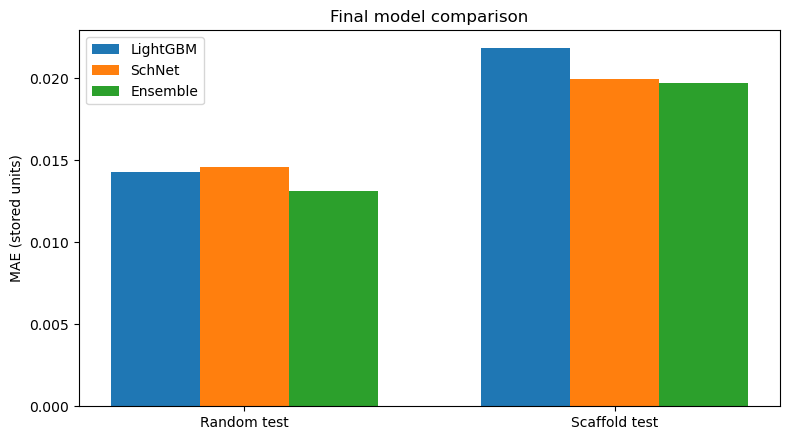

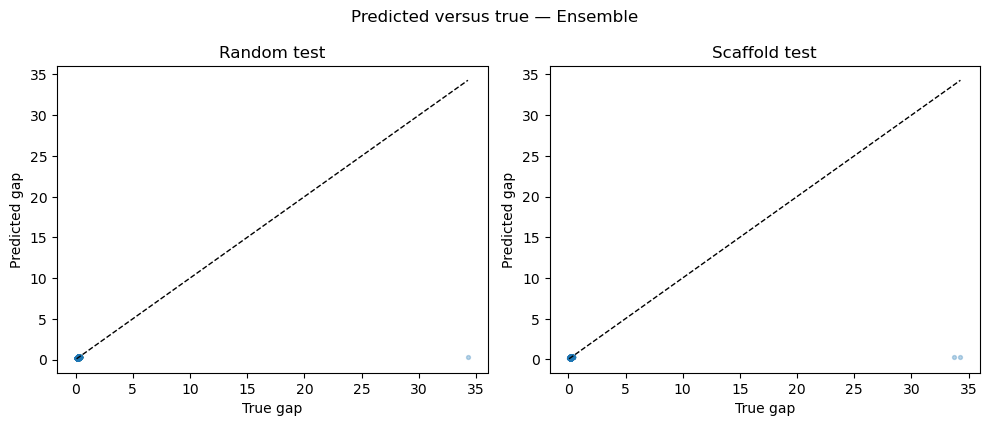

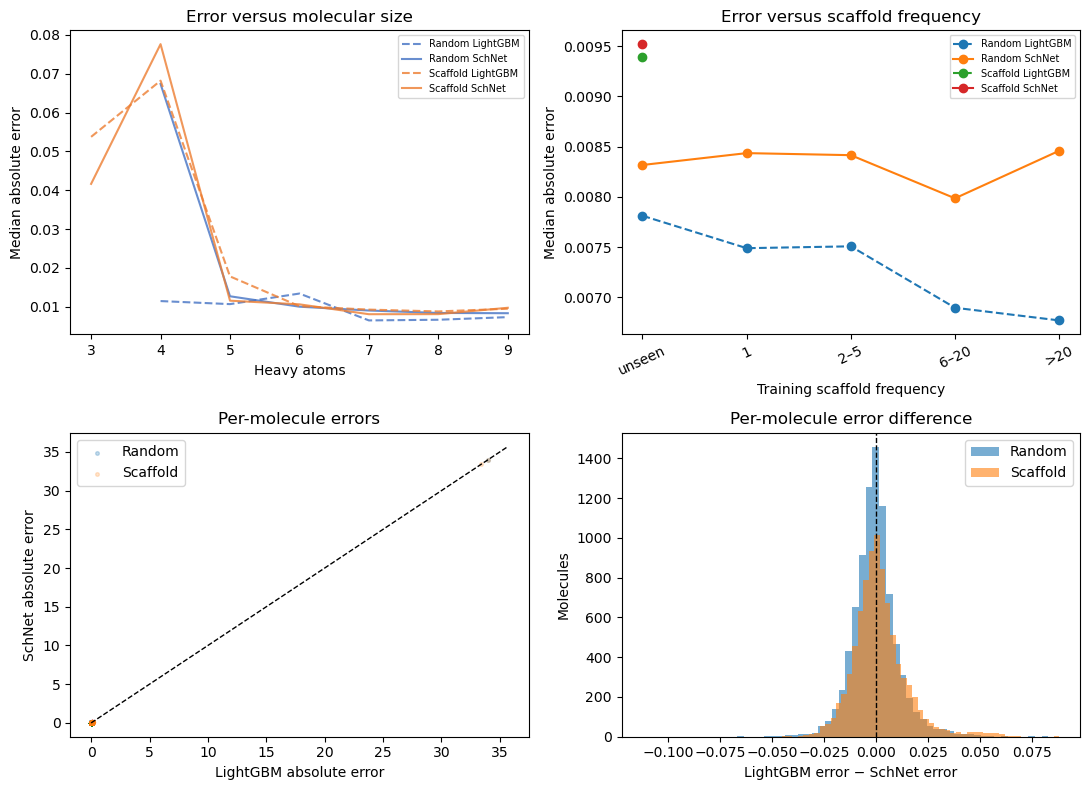

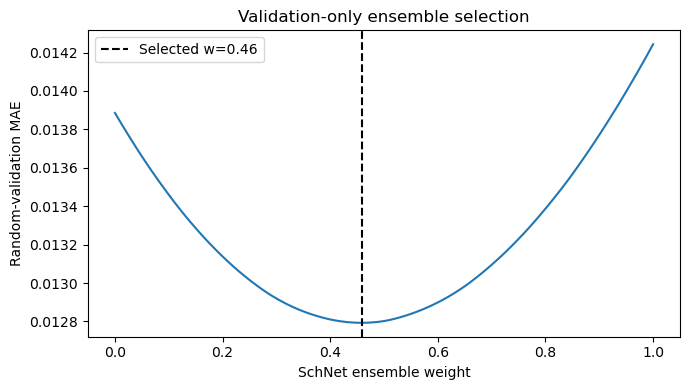

PosixPath('results/final_figures/04_ensemble_weight_validation.png')

In [7]:
plot_metrics = final_comparison.copy()
plot_metrics["short_model"] = plot_metrics["model"].replace({
    classical_family: "LightGBM",
    f"Ensemble (w={best_weight:.2f})": "Ensemble",
})
fig, ax = plt.subplots(figsize=(8, 4.5))
models = ["LightGBM", "SchNet", "Ensemble"]
x = np.arange(2)
width = .24
for offset, model in enumerate(models):
    values = [
        plot_metrics[(plot_metrics["split"] == split_name) & (plot_metrics["short_model"] == model)]["test_mae"].iloc[0]
        for split_name in ["random", "scaffold"]
    ]
    ax.bar(x + (offset - 1) * width, values, width, label=model)
ax.set(xticks=x, xticklabels=["Random test", "Scaffold test"],
       ylabel="MAE (stored units)", title="Final model comparison")
ax.legend()
savefig("01_model_comparison_mae")

random_validation_maes = {
    "LightGBM": mean_absolute_error(random_val_true, random_lgbm_val),
    "SchNet": mean_absolute_error(random_val_true, random_schnet_val),
    "Ensemble": validation_curve["validation_mae"].min(),
}
best_final_name = min(random_validation_maes, key=random_validation_maes.get)
if best_final_name == "LightGBM":
    best_random_pred, best_scaffold_pred = random_lgbm_test, scaffold_lgbm_test
elif best_final_name == "SchNet":
    best_random_pred, best_scaffold_pred = random_schnet_test, scaffold_schnet_test
else:
    best_random_pred, best_scaffold_pred = random_ensemble, scaffold_ensemble

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, split_name, true, pred in [
    (axes[0], "Random", random_test_true, best_random_pred),
    (axes[1], "Scaffold", scaffold_test_true, best_scaffold_pred),
]:
    ax.scatter(true, pred, s=8, alpha=.3)
    limits = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(limits, limits, "--", color="black", linewidth=1)
    ax.set(xlabel="True gap", ylabel="Predicted gap", title=f"{split_name} test")
fig.suptitle(f"Predicted versus true — {best_final_name}")
savefig("02_best_final_predicted_vs_true")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for frame, label, color in [
    (random_predictions, "Random", "#4472C4"),
    (scaffold_predictions, "Scaffold", "#ED7D31"),
]:
    size_summary = frame.groupby("n_heavy_atoms")[
        ["lightgbm_absolute_error", "schnet_absolute_error"]
    ].median()
    axes[0,0].plot(size_summary.index, size_summary["lightgbm_absolute_error"],
                   alpha=.8, label=f"{label} LightGBM", color=color, linestyle="--")
    axes[0,0].plot(size_summary.index, size_summary["schnet_absolute_error"],
                   alpha=.8, label=f"{label} SchNet", color=color)
axes[0,0].set(xlabel="Heavy atoms", ylabel="Median absolute error",
              title="Error versus molecular size")
axes[0,0].legend(fontsize=7)

frequency_bins = [-.5, .5, 1.5, 5.5, 20.5, np.inf]
frequency_labels = ["unseen", "1", "2–5", "6–20", ">20"]
for frame, label in [(random_predictions, "Random"), (scaffold_predictions, "Scaffold")]:
    binned = pd.cut(frame["scaffold_train_frequency"], frequency_bins, labels=frequency_labels)
    summary = frame.assign(freq_bin=binned).groupby("freq_bin", observed=False)[
        ["lightgbm_absolute_error", "schnet_absolute_error"]
    ].median()
    axes[0,1].plot(summary.index.astype(str), summary["lightgbm_absolute_error"],
                   marker="o", linestyle="--", label=f"{label} LightGBM")
    axes[0,1].plot(summary.index.astype(str), summary["schnet_absolute_error"],
                   marker="o", label=f"{label} SchNet")
axes[0,1].set(xlabel="Training scaffold frequency", ylabel="Median absolute error",
              title="Error versus scaffold frequency")
axes[0,1].tick_params(axis="x", rotation=25)
axes[0,1].legend(fontsize=7)

axes[1,0].scatter(random_predictions["lightgbm_absolute_error"],
                  random_predictions["schnet_absolute_error"], s=7, alpha=.25, label="Random")
axes[1,0].scatter(scaffold_predictions["lightgbm_absolute_error"],
                  scaffold_predictions["schnet_absolute_error"], s=7, alpha=.2, label="Scaffold")
maximum = max(axes[1,0].get_xlim()[1], axes[1,0].get_ylim()[1])
axes[1,0].plot([0, maximum], [0, maximum], "--", color="black", linewidth=1)
axes[1,0].set(xlabel="LightGBM absolute error", ylabel="SchNet absolute error",
              title="Per-molecule errors")
axes[1,0].legend()

axes[1,1].hist(random_predictions["schnet_improvement"], bins=60, alpha=.6, label="Random")
axes[1,1].hist(scaffold_predictions["schnet_improvement"], bins=60, alpha=.6, label="Scaffold")
axes[1,1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1,1].set(xlabel="LightGBM error − SchNet error", ylabel="Molecules",
              title="Per-molecule error difference")
axes[1,1].legend()
savefig("03_comparative_error_analysis")

plt.figure(figsize=(7, 4))
plt.plot(validation_curve["schnet_weight"], validation_curve["validation_mae"])
plt.axvline(best_weight, color="black", linestyle="--",
            label=f"Selected w={best_weight:.2f}")
plt.xlabel("SchNet ensemble weight")
plt.ylabel("Random-validation MAE")
plt.title("Validation-only ensemble selection")
plt.legend()
savefig("04_ensemble_weight_validation")

## 8. Final conclusions

In [8]:
random_scores = final_comparison.query("split == 'random'").set_index("model")["test_mae"]
scaffold_scores = final_comparison.query("split == 'scaffold'").set_index("model")["test_mae"]
ensemble_name = f"Ensemble (w={best_weight:.2f})"
random_winner = random_scores.idxmin()
scaffold_winner = scaffold_scores.idxmin()
random_ensemble_gain = min(
    random_scores["SchNet"], random_scores[classical_family]
) - random_scores[ensemble_name]
scaffold_ensemble_gain = min(
    scaffold_scores["SchNet"], scaffold_scores[classical_family]
) - scaffold_scores[ensemble_name]
random_residual_corr = residual_correlations.query("subset == 'random test'")["pearson"].iloc[0]
scaffold_residual_corr = residual_correlations.query("subset == 'scaffold test'")["pearson"].iloc[0]
random_rank_corr = residual_correlations.query("subset == 'random test'")["spearman"].iloc[0]
scaffold_rank_corr = residual_correlations.query("subset == 'scaffold test'")["spearman"].iloc[0]

delivery_model = (
    ensemble_name if random_ensemble_gain > 0 and scaffold_ensemble_gain >= 0
    else ("SchNet" if scaffold_scores["SchNet"] < scaffold_scores[classical_family]
          and random_scores["SchNet"] <= random_scores[classical_family] * 1.03
          else classical_family)
)

conclusion_text = f'''# Final conclusions

- **Best for interpolation:** `{random_winner}` has the lowest random-test MAE ({random_scores.min():.5f}).
- **Best for unseen scaffolds:** `{scaffold_winner}` has the lowest scaffold-test MAE ({scaffold_scores.min():.5f}).
- **Explicit geometry:** SchNet changes MAE by {random_scores[classical_family] - random_scores["SchNet"]:+.5f} on random test and {scaffold_scores[classical_family] - scaffold_scores["SchNet"]:+.5f} on scaffold test; its benefit is therefore concentrated where the positive difference is larger.
- **Error complementarity:** residual Pearson/Spearman correlations are {random_residual_corr:.3f}/{random_rank_corr:.3f} on random test and {scaffold_residual_corr:.3f}/{scaffold_rank_corr:.3f} on scaffold test. Pearson is dominated by shared extreme-target errors, while rank correlation better reflects typical-molecule complementarity.
- **Ensemble robustness:** validation selected `w={best_weight:.2f}` for SchNet. Relative to the better individual model, ensemble MAE improves by {random_ensemble_gain:+.5f} on random test and {scaffold_ensemble_gain:+.5f} on scaffold test.
- **Recommended delivery to Aqemia:** `{delivery_model}`. This recommendation prioritizes held-out MAE, scaffold robustness, and operational simplicity; the individual-molecule tables should guide follow-up inspection without causal overinterpretation.
'''
(RESULTS_DIR / "final_conclusions.md").write_text(conclusion_text, encoding="utf-8")
display(Markdown("## Final conclusions"))
display(Markdown(conclusion_text))

## Final conclusions

# Final conclusions

- **Best for interpolation:** `Ensemble (w=0.46)` has the lowest random-test MAE (0.01313).
- **Best for unseen scaffolds:** `Ensemble (w=0.46)` has the lowest scaffold-test MAE (0.01968).
- **Explicit geometry:** SchNet changes MAE by -0.00031 on random test and +0.00187 on scaffold test; its benefit is therefore concentrated where the positive difference is larger.
- **Error complementarity:** residual Pearson/Spearman correlations are 0.999/0.496 on random test and 1.000/0.573 on scaffold test. Pearson is dominated by shared extreme-target errors, while rank correlation better reflects typical-molecule complementarity.
- **Ensemble robustness:** validation selected `w=0.46` for SchNet. Relative to the better individual model, ensemble MAE improves by +0.00113 on random test and +0.00027 on scaffold test.
- **Recommended delivery to Aqemia:** `Ensemble (w=0.46)`. This recommendation prioritizes held-out MAE, scaffold robustness, and operational simplicity; the individual-molecule tables should guide follow-up inspection without causal overinterpretation.
